On ne crée plus de nouveaux modèles, on évalue et on améliore ceux qui existent dans le fichier 04_model_training dans ce projet.

Nous allons essayer de répondre à la question de base de notre projet:

`Quel modèle est le plus adapté à la prédiction du risque d'AVC ?`


In [38]:
# Bibliothèques
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier


from sklearn.metrics import (accuracy_score, 
                             classification_report,
                            precision_score,
                            recall_score,
                            f1_score,
                            confusion_matrix,
                            ConfusionMatrixDisplay
                        )



## Tableau comparatif des modèles de bases évalués et leurs métriques

Du notebook 04, il en ressort de nos différents modèles les résultats suivants :


In [2]:
results = pd.DataFrame(
    {
        "Modèles" : ["Logistic Regression",
                     "Decision Tree",
                     "Random Forest",
                     "XGBoost"
                  ],

        "Accuracy" : [0.714,
                      0.887,
                      0.923,
                      0.932
                  ],

          "Precision" : [0.13,
                         0.14,
                         0.13,
                         0.21  
                    ],

            "Recall" : [ 0.82,
                        0.26,
                        0.10,
                        0.14
                    ],
            
            "F1-score" : [ 0.22,
                           0.18,
                           0.11,
                           0.17
                     ]

    } 
)

display(results)



,Modèles,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.714,0.13,0.82,0.22
1,Decision Tree,0.887,0.14,0.26,0.18
2,Random Forest,0.923,0.13,0.10,0.11
3,XGBoost,0.932,0.21,0.14,0.17


## Analyse comparative des modèles de base

### Rappelons que l' objectif métier : 

Développer un modèle capable de détecter le plus grand nombre possible de patients à risque d'AVC. Dans ce contexte, le Recall est privilégié, car il permet de limiter les faux négatifs, qui représentent des patients malades non détectés.

### Analyse comparative

Après l'entraînement de 4 modèles de Machine Learning :

Régression Logistique, Decision Tree, Random Forest et XGBoost,

les performances ont été comparées à l'aide des métriques Accuracy, Precision, Recall et F1-score.

L'analyse met en évidence que :

la Régression Logistique est le modèle le plus adapté à notre problématique médicale, malgré une accuracy plus faible que les autres modèles.

En effet, son Recall de 82 % signifie qu'elle détecte la majorité des patients ayant réellement subi un AVC. Dans un contexte médical, cette métrique est prioritaire car l'objectif est de limiter le nombre de faux négatifs, c'est-à-dire les patients malades qui ne seraient pas détectés.

À l'inverse, XGBoost obtient la meilleure Accuracy (93,2 %). Cependant, son Recall n'est que de 14 %, ce qui signifie qu'il laisse échapper une grande partie des patients réellement atteints d'un AVC. Malgré une meilleure Precision (21 %), ce comportement le rend moins adapté à une utilisation médicale sans optimisation.

Le Random Forest présente également une très bonne Accuracy (92,3 %), mais son Recall de seulement 10 % montre qu'il détecte très peu de patients malades. Il privilégie donc la bonne classification des patients sains au détriment de la détection des AVC.

Enfin, le Decision Tree offre un compromis intermédiaire avec un Recall de 26 %, mais ses performances restent inférieures à celles de la Régression Logistique et il est plus sensible au surapprentissage.


### Conclusion

Dans un contexte de prédiction du risque d'AVC, la Régression Logistique est retenue comme modèle de référence, car elle maximise la détection des patients à risque, même si cela entraîne davantage de faux positifs. XGBoost est également retenu pour une phase d'optimisation, compte tenu de son potentiel et de sa très bonne Accuracy.

## Optimisation des hyperparamètres des modèles sélectionnés: Logistic Regression et XGBoost

### Première optimisation : Régression Logistique avec GridSearchCV

In [3]:
# chargeons nos variables balanced

X_train_balanced = pd.read_csv("../data/processed/X_train_balanced.csv")

y_train_balanced = pd.read_csv("../data/processed/y_train_balanced.csv")

print(X_train_balanced.shape)
print(y_train_balanced.shape)

print(type(X_train_balanced))
print(type(y_train_balanced))


(7776, 18)
(7776, 1)
<class 'pandas.DataFrame'>
<class 'pandas.DataFrame'>


In [4]:
# convertissons notre y_train_balanced en serie car il est en Dataframe

y_train_balanced = y_train_balanced.squeeze()

print(y_train_balanced.shape)

print(type(y_train_balanced))

(7776,)
<class 'pandas.Series'>


In [5]:
# créons notre modèle d'hyperparamétrage

param_grid = { "C" : [0.01, 0.1, 1 ,  10, 100] }

grid_lr = GridSearchCV(estimator=LogisticRegression(random_state=42),
             param_grid=param_grid,
             scoring="recall",
             cv=5,
             n_jobs=-1)



In [6]:
# entrainer notre modèle
grid_lr.fit(X_train_balanced, y_train_balanced)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with high

### Nous allons afficher les meilleurs paramètres obtenus

best_params_ est le ou les paramètres qui ont donné les meilleures performances selon la métrique scoring="recall" choisie .

In [37]:
# Meilleur paramètre

print("Meilleur Paramètre: ", grid_lr.best_params_)


Meilleur Paramètre:  {'C': 0.1}


C = 0.1 est celle qui a obtenu le meilleur Recall moyen pendant la validation croisée.
Ce qui veut dire que le modèle préfère une régularisation plus forte que celle par défaut (C = 1).

Donc pour notre jeu de données, un modèle un peu plus simple généralise légèrement mieux.


In [8]:
# Meilleur Recall Moyen
print("Meilleur Recall Moyen: ", grid_lr.best_score_)


Meilleur Recall Moyen:  0.8649687513440727


Recall Moyen = 0.865 est le Recall moyen obtenu pendant les 5 validations croisées sur notre jeu d'entraînement équilibré (X_train_balanced).

Il montre que le modèle est capable de retrouver en moyenne environ 86,5 % des patients AVC pendant son apprentissage.


In [12]:
# Récupérons le meilleur modèle
best_lr = grid_lr.best_estimator_

print(best_lr)


LogisticRegression(C=0.1, random_state=42)


In [15]:
# Importons notre jeu test final

X_test_final = pd.read_csv("../data/processed/X_test_final.csv")
# Affichons

display(X_test_final.head())

print(X_test_final.shape)

,gender_Male,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,age,avg_glucose_level,bmi,hypertension,heart_disease,senior,high_glucose,cardio_risk
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.674016,-0.497748,0.975775,1,0,0,0,1
1,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,-1.778282,-0.281950,-1.208633,0,0,0,0,0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.430250,-0.928896,0.277798,0,0,0,0,0
3,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.364822,-0.820997,1.803007,0,0,0,0,0
4,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.651103,-0.259564,0.032214,0,0,0,0,0


(1022, 18)


In [18]:
# Importons notre y_test
y_test = pd.read_csv("../data/processed/y_test.csv")

# conversion en serie pandas

y_test = y_test.squeeze()

print(y_test.shape)


(1022,)


In [16]:
# Prédire sur le jeu de test

y_pred_best_lr = best_lr.predict(X_test_final)


In [ ]:
# Calculons 

print("Accuracy: ", accuracy_score(y_test, y_pred_best_lr) )
print("Precision: ", precision_score(y_test, y_pred_best_lr) )
print("Recall: ", recall_score(y_test, y_pred_best_lr) )
print("F-1 score: ", f1_score(y_test, y_pred_best_lr) )


Accuracy:  0.7113502935420744
Precision:  0.1276595744680851
Recall:  0.84
F-1 score:  0.22163588390501318


In [21]:
# Affichons le report complet

print(classification_report(y_test, y_pred_best_lr) )


              precision    recall  f1-score   support

           0       0.99      0.70      0.82       972
           1       0.13      0.84      0.22        50

    accuracy                           0.71      1022
   macro avg       0.56      0.77      0.52      1022
weighted avg       0.95      0.71      0.79      1022



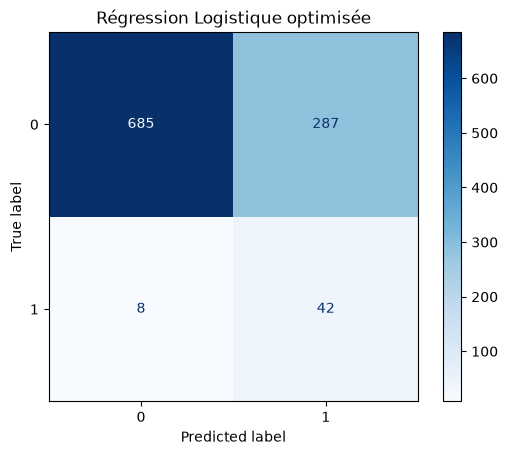

In [36]:
# Matrice de confusion

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best_lr, cmap='Blues')

plt.title("Régression Logistique optimisée")

plt.show()

Ce nouveau modèle détecte 1 patient AVC supplémentaire.

Par contre, il classe 4 patients sains supplémentaires comme étant à risque.

Nous Pouvons choisir d'accepter quelques faux positifs supplémentaires pour réduire le nombre de faux négatifs.


Nous allons répondre à la question de savoir si l'optimisation a réellement amélioré le modèle, ou les paramètres par défaut étaient-ils déjà les meilleurs ?

#### Optimisation de la Régression Logistique

L'optimisation des hyperparamètres à l'aide de GridSearchCV a identifié une valeur optimale de C = 0.1, correspondant à une régularisation plus forte que celle utilisée par défaut.

Cette optimisation améliore légèrement le Recall, qui passe de 82 % à 84 %, permettant au modèle de détecter un patient supplémentaire ayant réellement subi un AVC.

Cette amélioration entraîne une légère augmentation du nombre de faux positifs. L'Accuracy diminue légèrement (71,4 % → 71,1 %), tandis que la Precision et le F1-score restent pratiquement inchangés.

Ces résultats montrent que l'optimisation apporte un gain modéré, mais confirme que la Régression Logistique reste le modèle le plus adapté à notre objectif métier : détecter le plus grand nombre possible de patients à risque d'AVC.


### Seconde optimisation : XGBoost avec RandomizedSearchCV

RandomizedSearchCV nous permettra comme précédemment de détecter le plus de patients ayant réellement subi un AVC.

In [39]:
# Définissons la grille de recherche

param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

Les hyperparamètres réalisés contrôlent la complexité et le comportement du modèle avant son apprentissage. 
Ainsi, en les optimisant avec une méthode comme RandomizedSearchCV, on cherche à trouver la combinaison qui offre le meilleur compromis entre performances et capacité de généralisation, afin d'éviter le sous-apprentissage comme le surapprentissage.


In [40]:
# Créer le modèle
xgb_model = XGBClassifier(random_state = 42, eval_metric = "logloss")


In [ ]:
# Paramétrons et lançons notre RandomizedSearchCV

random_search = RandomizedSearchCV(
                                    estimator= xgb_model,
                                    param_distributions= param_dist,
                                    n_iter= 15,
                                    scoring= 'recall',
                                    cv=5,
                                    random_state= 42,
                                    n_jobs = -1
                                    )


In [55]:
# Entrainer

random_search.fit(X_train_balanced, y_train_balanced)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also 

### Nous allons afficher les meilleurs paramètres obtenus

In [56]:
print("best_params: ", random_search.best_params_)
print("best_score: ", random_search.best_score_)


best_params:  {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
best_score:  0.96888302183932


In [58]:
# récupérons le meilleur modèle

best_xgb = random_search.best_estimator_


In [59]:
# Prédictions

y_pred_best_xgb = best_xgb.predict(X_test_final)


Accuracy:  0.7964774951076321
Precision:  0.15350877192982457
Recall:  0.7
F-1 score:  0.2517985611510791

Classification report: 
              precision    recall  f1-score   support

           0       0.98      0.80      0.88       972
           1       0.15      0.70      0.25        50

    accuracy                           0.80      1022
   macro avg       0.57      0.75      0.57      1022
weighted avg       0.94      0.80      0.85      1022




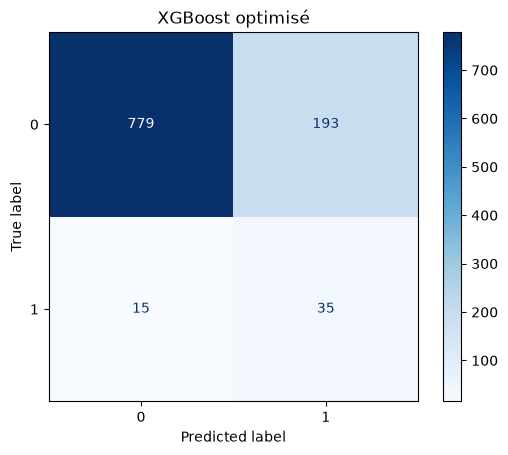

In [60]:
# Evaluons

print("Accuracy: ", accuracy_score(y_test, y_pred_best_xgb) )
print("Precision: ", precision_score(y_test, y_pred_best_xgb) )
print("Recall: ", recall_score(y_test, y_pred_best_xgb) )
print("F-1 score: ", f1_score(y_test, y_pred_best_xgb) )


print()

print(f"Classification report: \n{classification_report(y_test, y_pred_best_xgb)}")

print()

ConfusionMatrixDisplay.from_predictions(
                                        y_test,
                                        y_pred_best_xgb,
                                        cmap= "Blues"
                                        )

plt.title("XGBoost optimisé")

plt.show()


Notre matrice de confusion pour permet de voir que l'hyperoptimisation a plutôt bien fonctionné.
L'ancien XGBoost nous avait détecté seulement 7 patients, alors qu'actuellement, il détecte 35 patients.

Autrement dit, nous détectons 5 fois plus de patients AVC.

Notre modèle semble beaucoup plus prudent, avant nous avions FP= 26 et ensuite nous avons FP= 193

 Nous avons un Recall beaucoup plus amélioré de 70% contre 14% avant. 
 
 Parmi les 50 patients ayant réellement subi un AVC, le modèle en détecte maintenant 35. Avant il n'en détectait que 7.

 Bien qu ela Précision ait réduit de 21% à 15% actuellement.

 Parmi les patients que le modèle considère comme étant à risque, seulement 15 % feront réellement un AVC.


#### Optimisation de XGBoost

L'optimisation des hyperparamètres par RandomizedSearchCV a permis d'améliorer significativement la capacité du modèle à détecter les patients ayant réellement subi un AVC.

Le Recall est passé de 14 % à 70 %, ce qui représente une amélioration majeure de la sensibilité du modèle.

Cette amélioration s'accompagne toutefois d'une baisse de l'Accuracy (93 % à 80 %) et de la Precision (21 % à 15 %), conséquence directe d'une augmentation du nombre de faux positifs.

Dans un contexte de dépistage médical, ce compromis est acceptable, car il est préférable d'identifier un plus grand nombre de patients potentiellement à risque, quitte à réaliser des examens complémentaires sur certains patients finalement sains.


## Recaptitulatif de l'optimisation de nos modèles


In [ ]:
resultats_optimisation = pd.DataFrame({"Modèles": ["Regression Logistique Optimisée", "XGBoost Optimisé"],
                                        "Accuracy": [ "71 %", "80 %"],
                                        "Precision": [ "13 %", "15 %"],
                                        "Recall": [ "84 %", "70 %"],
                                        "F1-score": [ "0.22", "0.25"]

                                        })

resultats_optimisation


,Modèles,Accuracy,Precision,Recall,F1-score
0,Regression Logistique Optimisée,71 %,13 %,84 %,0.22
1,XGBoost Optimisé,80 %,15 %,70 %,0.25


l'objectif étant de détecter un maximum de patients à risque, la Régression Logistique optimisée reste le meilleur choix grâce à son Recall de 84 %.

Toutefois, si l'on cherche un meilleur compromis entre détection et précision, XGBoost optimisé devient très compétitif : il conserve un Recall élevé (70 %) tout en améliorant l'Accuracy, la Precision et le F1-score.


Nous concluons de ce fait que:

Dans notre étude, le modèle recommandé pour un outil de dépistage médical : Régression Logistique optimisée, car elle minimise les faux négatifs (Recall 84 %).

Le meilleur modèle d'ensemble (équilibre global) : XGBoost optimisé, qui offre un compromis plus équilibré entre Recall, Precision, F1-score et Accuracy.


## Tableau Global de tous nos modèles utilisés

In [91]:
tableau_global = pd.DataFrame({
    "Modèle": [
        "Régression Logistique",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "Régression Logistique optimisée",
        "XGBoost optimisé"
    ],
    "Accuracy": [0.714, 0.887, 0.923, 0.932, 0.711, 0.796],
    "Precision (AVC)": [0.13, 0.14, 0.13, 0.21, 0.13, 0.15],
    "Recall (AVC)": [0.82, 0.26, 0.10, 0.14, 0.84, 0.70],
    "F1-score": [0.22, 0.18, 0.11, 0.17, 0.22, 0.25],

    "Force": ["Détecte la majorité des patients AVC",
              "Bonne accuracy, modèle simple à interpréter",
               " Très bonne accuracy, robuste",
                "Meilleure accuracy avant optimisation",
                "Meilleur Recall du projet",
                " Excellent compromis entre Recall et Accuracy"],

    "Limites": ["Beaucoup de faux positifs",
                "Trop de faux négatifs",
                " Détecte très peu d'AVC",
                "Recall insuffisant pour un contexte médical",
                "Accuracy plus faible",
                " Plus de faux positifs"],

        "Recommandation" : ["Bon modèle de dépistage",
              "Non retenu",
               "Non retenu",
                "Non retenu sans optimisation",
                "🩺 Meilleur modèle pour le dépistage médical",
                " ⚖️ Meilleur compromis global"],

        "Objectif métier"  : ["🧬 Dépistage précoce des patients à risque",
              "Interprétation pédagogique",
               "Comparaison de modèles d'ensemble",
                "Optimisation des performances globales",
                "✅ Modèle retenu pour le dépistage médical",
                " ⚖️ Modèle alternatif offrant un meilleur équilibre"]    
})

tableau_global


,Modèle,Accuracy,Precision (AVC),Recall (AVC),F1-score,Force,Limites,Recommandation,Objectif métier
0,Régression Logistique,0.714,0.13,0.82,0.22,Détecte la majorité des patients AVC,Beaucoup de faux positifs,Bon modèle de dépistage,🧬 Dépistage précoce des patients à risque
1,Decision Tree,0.887,0.14,0.26,0.18,"Bonne accuracy, modèle simple à interpréter",Trop de faux négatifs,Non retenu,Interprétation pédagogique
2,Random Forest,0.923,0.13,0.10,0.11,"Très bonne accuracy, robuste",Détecte très peu d'AVC,Non retenu,Comparaison de modèles d'ensemble
3,XGBoost,0.932,0.21,0.14,0.17,Meilleure accuracy avant optimisation,Recall insuffisant pour un contexte médical,Non retenu sans optimisation,Optimisation des performances globales
4,Régression Logistique optimisée,0.711,0.13,0.84,0.22,Meilleur Recall du projet,Accuracy plus faible,🩺 Meilleur modèle pour le dépistage médical,✅ Modèle retenu pour le dépistage médical
5,XGBoost optimisé,0.796,0.15,0.70,0.25,Excellent compromis entre Recall et Accuracy,Plus de faux positifs,⚖️ Meilleur compromis global,⚖️ Modèle alternatif offrant un meilleur équi...



### Conclusion Général

Les modèles présentant les meilleures Accuracy (Random Forest et XGBoost avant optimisation) ne sont pas les plus adaptés à un problème de dépistage médical. En effet, leur faible Recall conduit à manquer un grand nombre de patients réellement atteints d'un AVC.

Après optimisation des hyperparamètres, la Régression Logistique obtient le meilleur Recall (84 %), ce qui en fait le modèle le plus adapté à un objectif de dépistage. De son côté, XGBoost optimisé offre le meilleur compromis entre Recall, Precision, F1-score et Accuracy, constituant une alternative pertinente lorsque l'on cherche à limiter les faux positifs tout en conservant une bonne capacité de détection.


## Graphique Comparatif


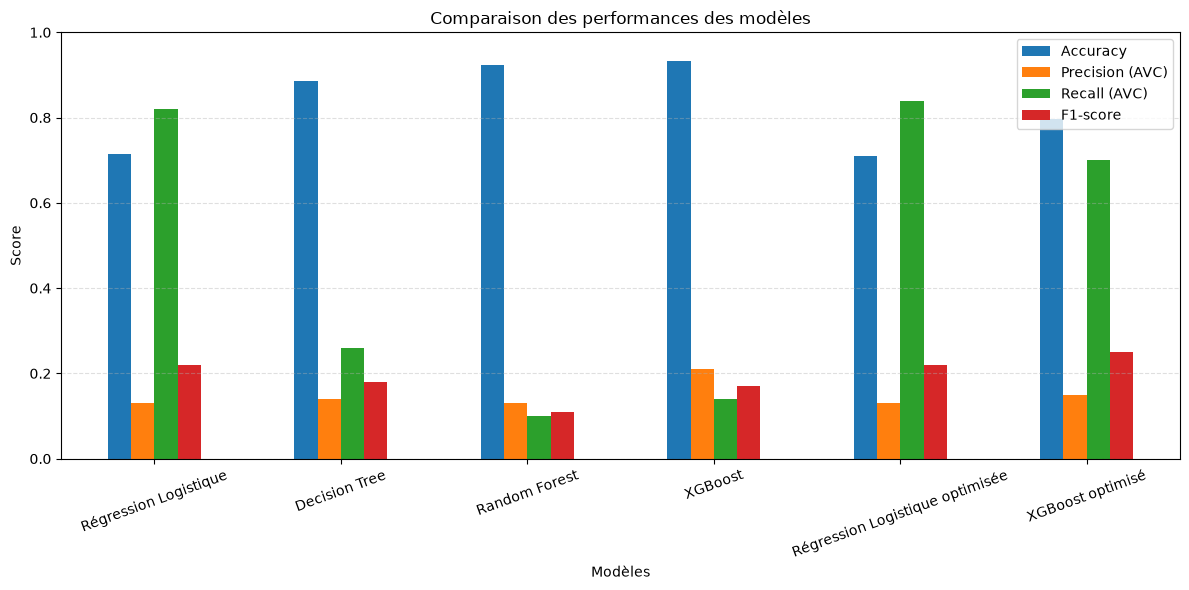

In [95]:
tableau_global_plot = tableau_global.set_index("Modèle")

tableau_global_plot.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Comparaison des performances des modèles")
plt.ylabel("Score")
plt.xlabel("Modèles")
plt.ylim(0,1)

plt.xticks(rotation=20)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.legend(loc="upper right")

plt.tight_layout()

plt.show()

## Analyse comparative des modèles

